# Benchmark Speed Analysis

1. Prepare datasets - choose different pairs of treatment and control bam files aligned on the `hg38` for benchmark.
2. Copy these pairs under `bams1`, `bams2`, ..., `bamsN` folder.
3. Launch the script with logging to capture benchmark data:
```bash
benchmark.sh 2>&1 | tee benchmark.txt
```
4. Execute this notebook to analyze the benchmark data.


In [10]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import numpy as np
import os
import re
import tempfile
sns.set_theme(style="whitegrid")


In [11]:
BENCHMARK_FILE = os.path.expanduser('~/data/2025_benchmark/benchmark.txt')

In [12]:
def parse_benchmark_file(file_path):
    results = []
    current_block = None
    in_job_section = False
    current_job = None

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()

            # Start of a new bam block
            if re.match('^bams[1-5]$', line.strip()):
                current_stats = []
                current_block = {'name': line, 'stats': current_stats}
                results.append(current_block)
                in_job_section = False
                continue

            # Start of job stats section
            if line.startswith('Job stats:'):
                in_job_section = True
                current_job = {}
                current_stats.append(current_job)
                continue

            # Handle stats section
            if in_job_section:
                if line.startswith('total'):
                    in_job_section = False
                elif line.startswith("call_"):
                    current_job['name'] = line.split(' ')[0]
                continue

            # Look for real time
            if line.startswith('real'):
                if 'real_time' not in current_job:
                    current_job['real_time'] = re.sub(',[0-9]+', '', line.split('\t')[1].strip())
                continue

    return results

In [13]:
results = parse_benchmark_file(BENCHMARK_FILE)
results

[{'name': 'bams1',
  'stats': [{'name': 'call_peaks_macs2', 'real_time': '0m59s'},
   {'name': 'call_peaks_macs2', 'real_time': '1m10s'},
   {'name': 'call_peaks_sicer', 'real_time': '4m14s'},
   {'name': 'call_peaks_span', 'real_time': '6m18s'},
   {'name': 'call_peaks_macs3', 'real_time': '1m29s'},
   {'name': 'call_peaks_macs3', 'real_time': '1m38s'},
   {'name': 'call_peaks_sicer2', 'real_time': '0m54s'},
   {'name': 'call_peaks_homer', 'real_time': '1m2s'},
   {'real_time': '0m9s'},
   {'name': 'call_peaks_peakseq', 'real_time': '11m31s'},
   {'name': 'call_peaks_fseq2', 'real_time': '1m59s'},
   {'name': 'call_peaks_lanceotron', 'real_time': '14m2s'}]},
 {'name': 'bams2',
  'stats': [{'name': 'call_peaks_macs2', 'real_time': '1m8s'},
   {'name': 'call_peaks_macs2', 'real_time': '1m8s'},
   {'name': 'call_peaks_sicer', 'real_time': '6m14s'},
   {'name': 'call_peaks_span', 'real_time': '7m24s'},
   {'name': 'call_peaks_macs3', 'real_time': '1m41s'},
   {'name': 'call_peaks_macs3', 

In [14]:
rows = []
for block in results:
    name = block['name']
    for job in block['stats']:
        if 'name' not in job:
            continue
        peak_caller = job['name'].replace('call_peaks_', '')
        real_time = job['real_time']
        time = re.split('[ms]', real_time)
        time_sec = 60 * int(time[0]) + int(time[1])
        rows.append((name, peak_caller, time_sec))
    rows.append((name, 'bayespeak', 1.5 * 60 * 60))  # 1.5 hours
    rows.append((name, 'gps', 2 * 60 * 60))  # 2 hours

df = pd.DataFrame(rows, columns=['block', 'tool', 'time'])
df.loc[df['tool'] == 'macs2', 'tool'] = 'MACS2'
df.loc[df['tool'] == 'macs3', 'tool'] = 'MACS3'
df.loc[df['tool'] == 'sicer', 'tool'] = 'SICER'
df.loc[df['tool'] == 'sicer2', 'tool'] = 'SICER2'
df.loc[df['tool'] == 'homer', 'tool'] = 'HOMER'
df.loc[df['tool'] == 'hotspot', 'tool'] = 'Hotspot'
df.loc[df['tool'] == 'peakseq', 'tool'] = 'Peakseq'
df.loc[df['tool'] == 'omnipeak', 'tool'] = 'Omnipeak'
df.loc[df['tool'] == 'bayespeak', 'tool'] = 'BayesPeak'
df.loc[df['tool'] == 'gps', 'tool'] = 'GPS'
df.loc[df['tool'] == 'lanceotron', 'tool'] = 'LanceOtron'
df

,block,tool,time
0,bams1,MACS2,59.0
1,bams1,MACS2,70.0
2,bams1,SICER,254.0
3,bams1,Omnipeak,378.0
4,bams1,MACS3,89.0
...,...,...,...
75,bams4,BayesPeak,5400.0
76,bams4,GPS,7200.0
77,bams5,Hotspot,55.0
78,bams5,BayesPeak,5400.0


In [15]:
df['tool'].unique()

array(['MACS2', 'SICER', 'Omnipeak', 'MACS3', 'SICER2', 'HOMER',
       'Peakseq', 'fseq2', 'LanceOtron', 'BayesPeak', 'GPS', 'Hotspot'],
      dtype=object)

In [16]:
import matplotlib.colors as mc
import colorsys
def adjust_lightness(c, amount=0.5):
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

TOOLS = ['MACS2', 'SICER', 'Omnipeak', 'HOMER', 'Hotspot', 'Peakseq', 'LanceOtron']
palette = plt.get_cmap('tab10')
TOOLS_PALETTE = {t: palette(i) for i, t in enumerate(TOOLS)}

TOOLS_PALETTE['MACS2 broad'] = adjust_lightness(TOOLS_PALETTE['MACS2'])
TOOLS_PALETTE['HOMER histone'] = adjust_lightness(TOOLS_PALETTE['HOMER'])

TOOLS_OTHER = ['MACS3', 'SICER2', 'BayesPeak', 'GPS']
palette = plt.get_cmap('tab20')
for i, tool in enumerate(TOOLS_OTHER):
    TOOLS_PALETTE[tool] = palette(19 - i)

# Tools by speed
# TOOLS = ['MACS2', 'SICER2', 'HOMER', 'MACS3', 'Hotspot', 'SICER', 'Omnipeak', 'Peakseq', 'BayesPeak', 'GPS', 'LanceOtron']
TOOLS = ['MACS2', 'HOMER', 'Hotspot', 'SICER', 'Omnipeak', 'Peakseq', 'LanceOtron', 'BayesPeak', 'GPS']

Time


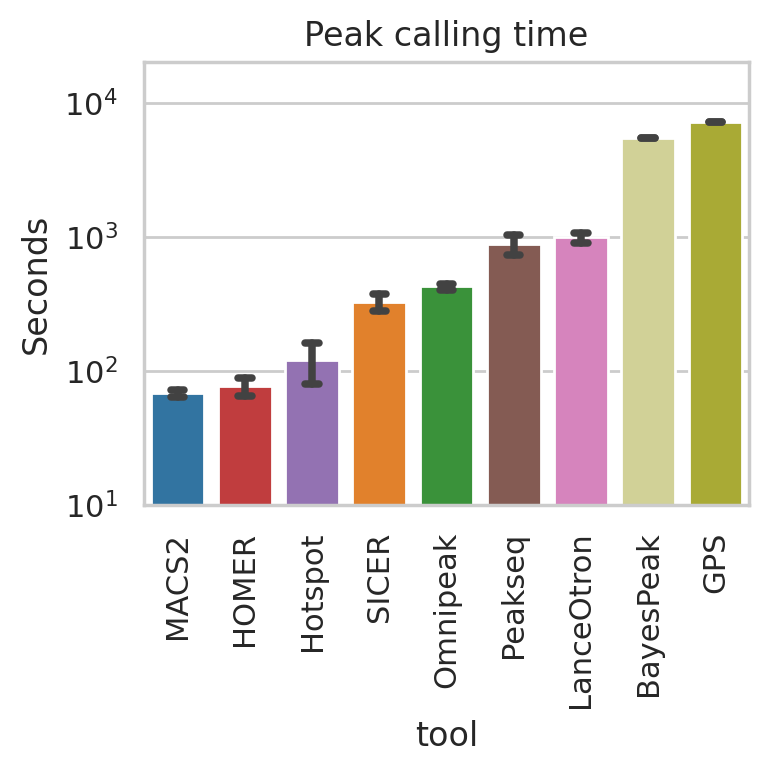

In [17]:
print('Time')
plt.figure(figsize=(4, 4))
ax = plt.axes()
ax.title.set_text('Peak calling time')
g_results = sns.barplot(data=df, x='tool', y='time',
                        order=TOOLS,
                        palette=TOOLS_PALETTE,
                        capsize=.2,
                        ax=ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set(yscale='log')
ax.set_ylim((10, 2e4))
ax.set_ylabel('Peak caller')
ax.set_ylabel('Seconds')
plt.tight_layout()
plt.show()

# Performance ranking

In [19]:
# Rank tools within each block by time (lower time => better rank 1)
df_ranked = df.copy()
df_ranked['rank'] = (
    df_ranked
    .groupby('block', group_keys=False)['time']
    .rank(method='min', ascending=True)
)

# Optional: inspect ranks for a few rows
df_ranked.head()

,block,tool,time,rank
0,bams1,MACS2,59.0,2.0
1,bams1,MACS2,70.0,5.0
2,bams1,SICER,254.0,9.0
3,bams1,Omnipeak,378.0,10.0
4,bams1,MACS3,89.0,6.0


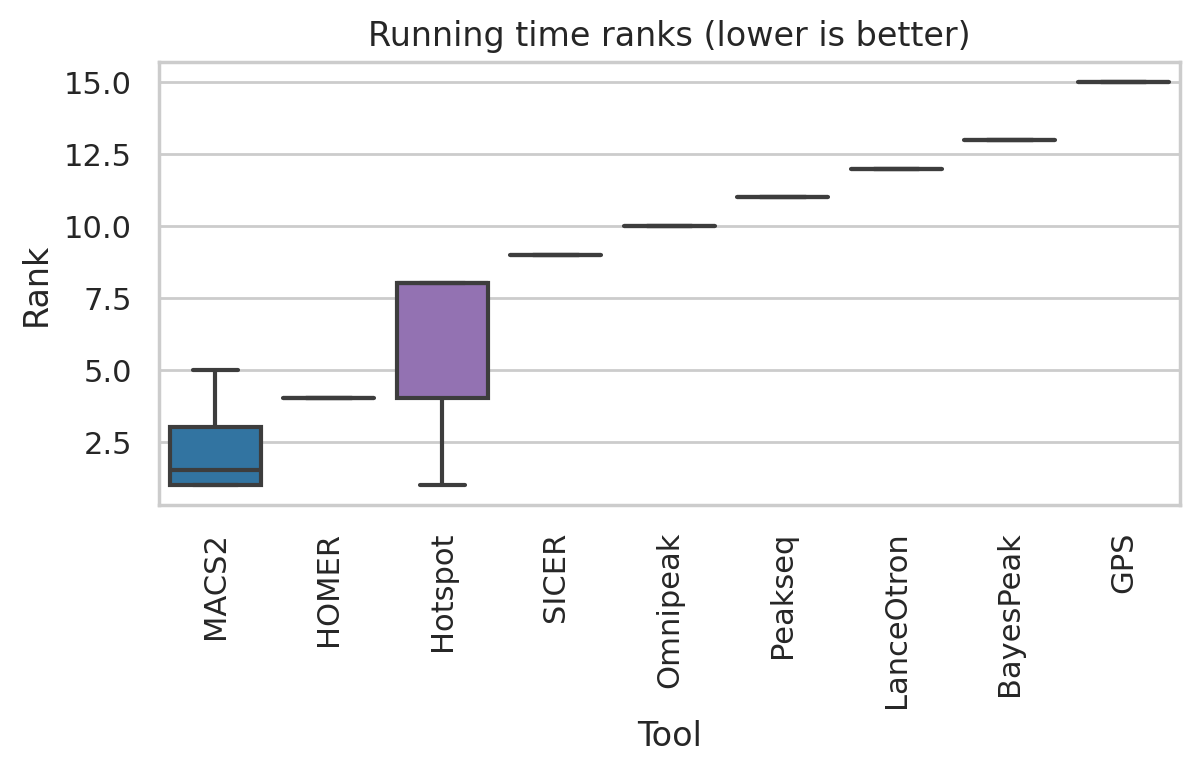

In [27]:
plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.set_title('Running time ranks (lower is better)')

# Add a boxplot overlay for central tendency/spread (optional)
sns.boxplot(
    data=df_ranked, x='tool', y='rank',
    order=TOOLS,
    palette=TOOLS_PALETTE,
    showfliers=False,
    ax=ax
)

ax.set_xlabel('Tool')
ax.set_ylabel('Rank')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()